In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
par_rates_data = pd.read_csv('treasury_yield_curve.csv')
par_rates_data

,Date,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
0,2020-01-01,1.53,1.55,1.56,1.53,1.52,1.52,1.56,1.67,1.76,2.07,2.22
1,2020-02-01,1.58,1.54,1.51,1.41,1.33,1.31,1.32,1.42,1.50,1.81,1.97
2,2020-03-01,0.37,0.30,0.30,0.33,0.45,0.50,0.59,0.78,0.87,1.26,1.46
3,2020-04-01,0.11,0.14,0.17,0.18,0.22,0.28,0.39,0.55,0.66,1.06,1.27
4,2020-05-01,0.10,0.13,0.15,0.16,0.17,0.22,0.34,0.53,0.67,1.12,1.38
...,...,...,...,...,...,...,...,...,...,...,...,...
73,2026-02-01,3.72,3.69,3.60,3.48,3.47,3.52,3.68,3.89,4.13,4.70,4.76
74,2026-03-01,3.74,3.72,3.72,3.67,3.71,3.73,3.85,4.04,4.25,4.83,4.85
75,2026-04-01,3.69,3.70,3.72,3.69,3.80,3.82,3.94,4.12,4.32,4.89,4.91
76,2026-05-01,3.71,3.69,3.77,3.79,4.00,4.04,4.15,4.31,4.48,5.03,5.03


In [3]:
# set date as index and convert to datetime
par_rates_data['Date'] = pd.to_datetime(par_rates_data['Date'])
par_rates_data = par_rates_data.set_index('Date')

# define maturities in years
maturities = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]
maturity_labels = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

print('Date range:', par_rates_data.index[0].date(), 'to', par_rates_data.index[-1].date())
print('Maturities:', maturity_labels)
print(par_rates_data.head(5))

Date range: 2020-01-01 to 2026-06-01
Maturities: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
              1M    3M    6M    1Y    2Y    3Y    5Y    7Y   10Y   20Y   30Y
Date                                                                        
2020-01-01  1.53  1.55  1.56  1.53  1.52  1.52  1.56  1.67  1.76  2.07  2.22
2020-02-01  1.58  1.54  1.51  1.41  1.33  1.31  1.32  1.42  1.50  1.81  1.97
2020-03-01  0.37  0.30  0.30  0.33  0.45  0.50  0.59  0.78  0.87  1.26  1.46
2020-04-01  0.11  0.14  0.17  0.18  0.22  0.28  0.39  0.55  0.66  1.06  1.27
2020-05-01  0.10  0.13  0.15  0.16  0.17  0.22  0.34  0.53  0.67  1.12  1.38


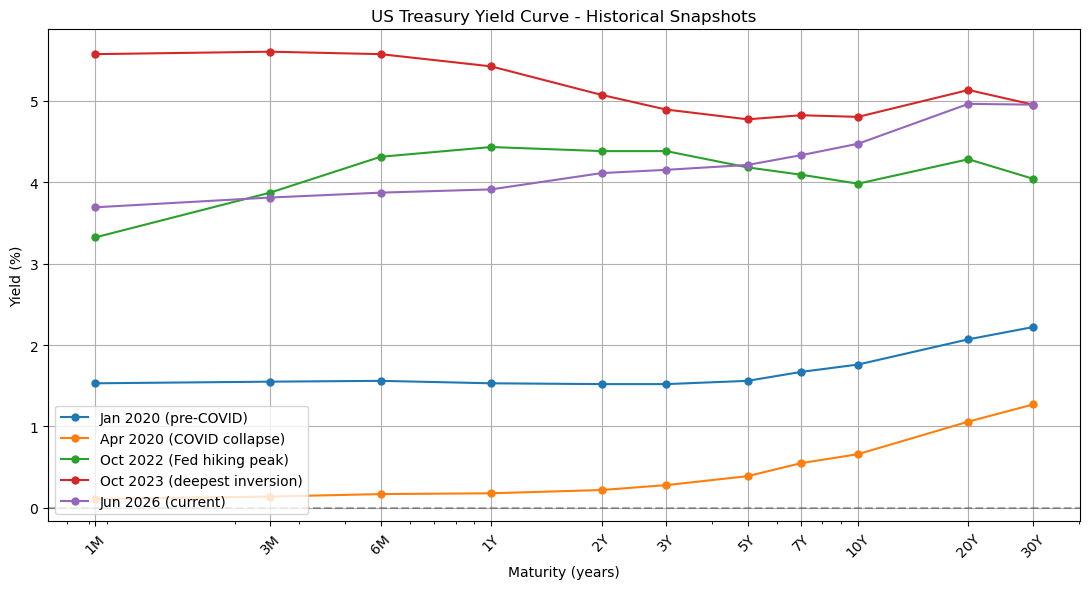

In [4]:
# Five dates to see a macro story
snapshot_dates = ['2020-01-01', '2020-04-01', '2022-10-01', '2023-10-01', '2026-06-01']
snapshot_labels = ['Jan 2020 (pre-COVID)', 'Apr 2020 (COVID collapse)', 
                   'Oct 2022 (Fed hiking peak)', 'Oct 2023 (deepest inversion)', 
                   'Jun 2026 (current)']

fig, ax = plt.subplots(figsize=(11,6))

for date, label in zip(snapshot_dates, snapshot_labels):
    yields = par_rates_data.loc[date, maturity_labels].values
    ax.plot(maturities, yields, marker='o', markersize=5, label=label)
    
# marking 2Y10Y inversion zone
ax.axhline(0, color='black', linestyle='--', alpha=0.3)

ax.set_title('US Treasury Yield Curve - Historical Snapshots')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_xscale('log')
ax.set_xticks(maturities)
ax.set_xticklabels(maturity_labels, rotation=45)
ax.legend(loc='lower left')
ax.grid(True)
fig.tight_layout()
plt.show()
fig.savefig('yield_curve_snapshots.png')

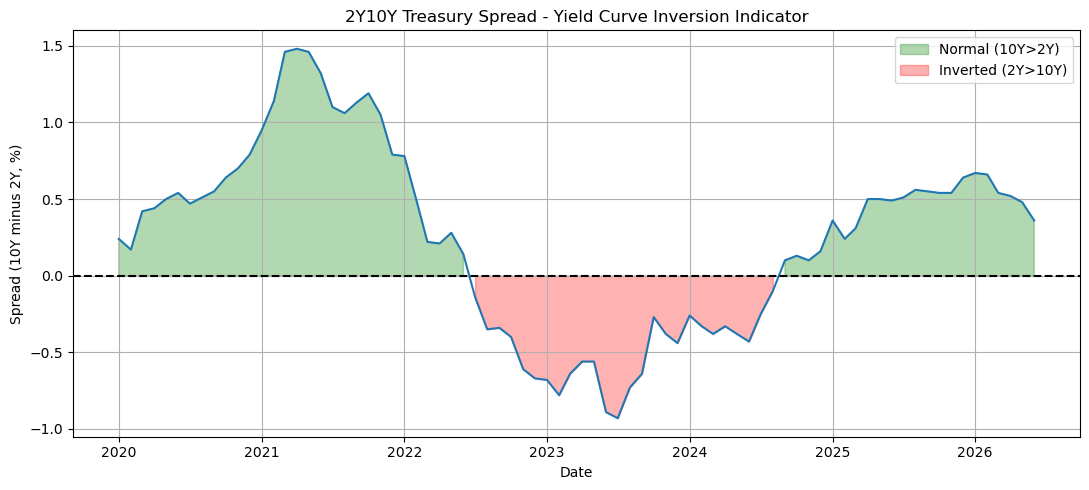

Deepest inversion: -0.93%
Current spread: 0.36%


In [5]:
# 2Y10Y - the classic recession indicator
spread = par_rates_data['10Y'] - par_rates_data['2Y']

fig, ax = plt.subplots(figsize=(11,5))

# fill in green when positive, red when negative
ax.fill_between(par_rates_data.index, spread, 0, where=(spread>=0), color='green', alpha=0.3, label='Normal (10Y>2Y)')
ax.fill_between(par_rates_data.index, spread, 0, where=(spread<0), color='red', alpha=0.3, label='Inverted (2Y>10Y)')

ax.plot(par_rates_data.index, spread)
ax.axhline(0, color='black', linestyle='--')

ax.set_title('2Y10Y Treasury Spread - Yield Curve Inversion Indicator')
ax.set_xlabel('Date')
ax.set_ylabel('Spread (10Y minus 2Y, %)')
ax.legend(loc='upper right')
ax.grid(True)
fig.tight_layout()
plt.show()
fig.savefig('2y10y_spread.png')

print(f'Deepest inversion: {spread.min():.2f}%')
print(f'Current spread: {spread.iloc[-1]:.2f}%')

In [6]:
# Bootstrapping zero-coupon curve

def bootstrap_zero_curve(par_rates_row, maturities):
    """ function that bootstraps zero-coupon rates from par yields.
        par_rates_row: array of par yields as decimals (e.g. [0.04, 0.05, ...])
        maturities: array of maturitiesin years ([0.25, 0.5, 1, 2, ...])
        returns array of zero rates as decimals
    """
    zero_rates = np.zeros(len(maturities))
    
    for i, (T,c) in enumerate(zip(maturities, par_rates_row)):
        # for maturities up to 1 year: single cash flow, zero rate = par yield
        if T <= 1:
            zero_rates[i] = c
        # For maturities > 1 year: bootstrap using previously found zero rates
        # Sum the PV of all coupon payments before maturity
        # using annual coupons for simplicity
        else:
            coupon_pv = 0
            for t in range(1, int(T)):
                # interpolate zero rate at year t
                z_t = np.interp(t, maturities[:i], zero_rates[:i])
                coupon_pv += c / (1 + z_t) ** t
                
            # solve for zero rate at maturity T
            zero_rates[i] = (1 + c) ** (1/T) - 1
            remaining_pv = 1 - coupon_pv
            zero_rates[i] = ((1 + c) / remaining_pv) ** (1/T) - 1
        
    return zero_rates
            

# Bootstrap zero curve for a specific date
# Converting par yields to decimals
date = '2026-01-01'
par_rates_decimal = par_rates_data.loc[date, maturity_labels].values / 100

zero_rates = bootstrap_zero_curve(par_rates_decimal, maturities)

print('Par yields vs Zero rates for', date)
print(f"{'Maturity':<10} {'Par Yield':>12} {'Zero Rate':>12} {'Difference':>12}")
for label, par, zero in zip(maturity_labels, par_rates_decimal, zero_rates):
    diff = (zero - par) * 100
    print(f'{label:<10} {par*100:>11.3f}% {zero*100:>11.3f}% {diff:>+11.3f}%')

Par yields vs Zero rates for 2026-01-01
Maturity      Par Yield    Zero Rate   Difference
1M               3.730%       3.730%      +0.000%
3M               3.670%       3.670%      +0.000%
6M               3.590%       3.590%      +0.000%
1Y               3.510%       3.510%      +0.000%
2Y               3.540%       3.541%      +0.001%
3Y               3.610%       3.613%      +0.003%
5Y               3.780%       3.795%      +0.015%
7Y               3.990%       4.026%      +0.036%
10Y              4.210%       4.281%      +0.071%
20Y              4.790%       5.204%      +0.414%
30Y              4.840%       4.933%      +0.093%


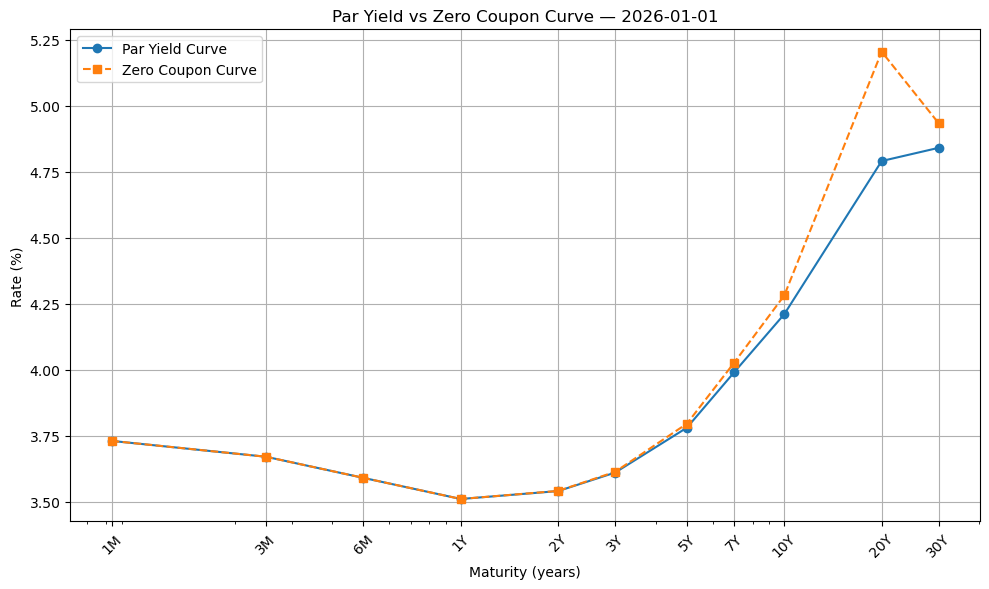

In [7]:
# visualization for the par curve vs zero curve
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(maturities, par_rates_decimal * 100, marker='o', label='Par Yield Curve')
ax.plot(maturities, zero_rates * 100, marker='s', linestyle='--', label='Zero Coupon Curve')

ax.set_title(f'Par Yield vs Zero Coupon Curve — {date}')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Rate (%)')
ax.set_xscale('log')
ax.set_xticks(maturities)
ax.set_xticklabels(maturity_labels, rotation=45)
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()
fig.savefig('par_vs_zero_curve.png')

In [8]:
def forward_rates(zero_rates, maturities):
    """ function that calculates forward rates from zero rates.
        The forward rate between maturity[i-1] and maturity[i]
        tells us the implied rate for that future period
    """
    forwards = []
    
    for i in range(1, len(maturities)):
        T1 = maturities[i-1]
        T2 = maturities[i]
        z1 = zero_rates[i-1]
        z2 = zero_rates[i]
        
        f = ((1 + z2)**T2 / (1 + z1)**T1)**(1 / (T2 - T1)) - 1
        
        forwards.append(f)
        
    return np.array(forwards)

# calculate forward rates from bootstrapped zero curve
forwards = forward_rates(zero_rates, maturities)

# forward rate labels
forward_labels = [f"{maturity_labels[i-1]}-{maturity_labels[i]}" for i in range(1, len(maturity_labels))]

print(f"\nForward rates for {date}")
print(f"{'Period':<12} {'Zero T1':>10} {'Zero T2':>10} {'Forward':>10}")
for label, z1, z2, f in zip(forward_labels, zero_rates[:-1], zero_rates[1:], forwards):
    print(f"{label:<12} {z1*100:>9.3f}% {z2*100:>9.3f}% {f*100:>9.3f}%")


Forward rates for 2026-01-01
Period          Zero T1    Zero T2    Forward
1M-3M            3.730%     3.670%     3.640%
3M-6M            3.670%     3.590%     3.510%
6M-1Y            3.590%     3.510%     3.430%
1Y-2Y            3.510%     3.541%     3.571%
2Y-3Y            3.541%     3.613%     3.758%
3Y-5Y            3.613%     3.795%     4.069%
5Y-7Y            3.795%     4.026%     4.606%
7Y-10Y           4.026%     4.281%     4.877%
10Y-20Y          4.281%     5.204%     6.135%
20Y-30Y          5.204%     4.933%     4.394%


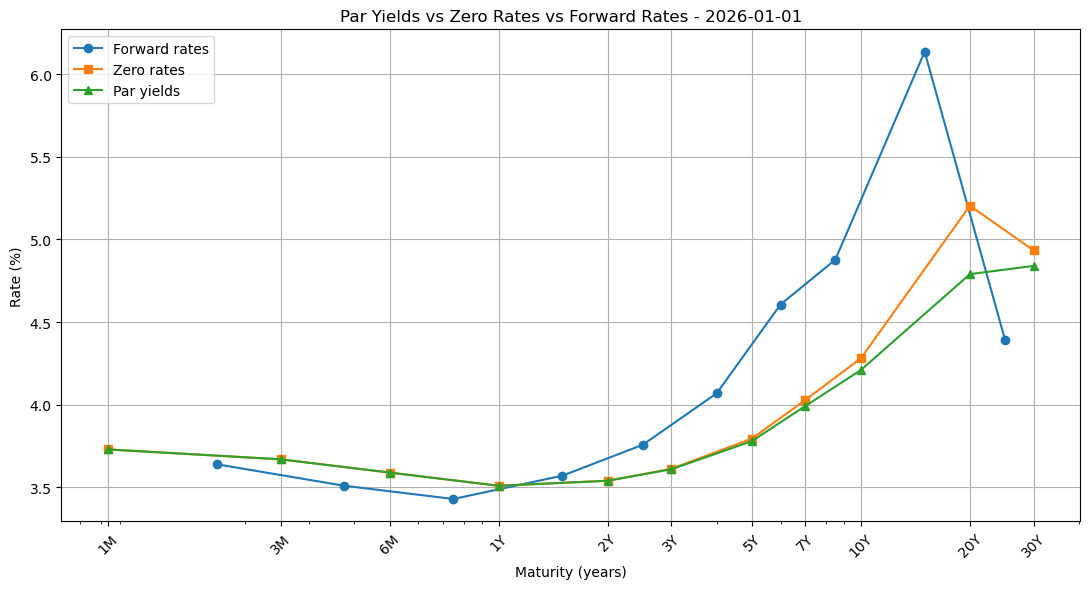

In [9]:
# visualization of the forward curve, zero curve, and par yields
fig, ax = plt.subplots(figsize=(11, 6))

# Forward rates (plot at the midpoint of each period)
forward_maturities = [(maturities[i-1] + maturities[i]) / 2 for i in range(1, len(maturities))]

ax.plot(forward_maturities, [f*100 for f in forwards], marker='o', label='Forward rates')
ax.plot(maturities, zero_rates*100, marker='s', label='Zero rates')
ax.plot(maturities, par_rates_decimal*100, marker='^', label='Par yields')

ax.set_title(f'Par Yields vs Zero Rates vs Forward Rates - {date}')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Rate (%)')
ax.set_xscale('log')
ax.set_xticks(maturities)
ax.set_xticklabels(maturity_labels, rotation=45)
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig('par_zero_forward_curve.png', dpi=150, bbox_inches='tight')
plt.show()